### Team Members:


In [1]:
# Importing our packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

# Loading our movies dataset
movies = pd.read_csv("tmdb_5000_movies.csv")

# Introduction

The film industry is a high-risk, high-reward environment where production budgets can range from thousands to hundreds of millions of dollars. Despite the availability of historical data, predicting whether a movie will be financially successful remains a challenging problem. Studios must make investment decisions before release, often relying on incomplete or uncertain information.

In this project, we aim to use data-driven techniques to better understand what factors contribute to a movie’s financial success. By leveraging historical movie data, we can identify patterns and build predictive models that may assist in decision-making.

### Project Goal

The primary goal of this project is to classify whether a movie is a financial <strong>hit</strong> or  <strong>flop</strong> based on its characteristics. Rather than using raw revenue as a measure of success, we define success using Return on Investment (ROI): 
$$
ROI = \frac{Revenue - Budget}{Budget}
$$
Using ROI provides a more meaningful measure of financial performance, as it accounts for the scale of investment. 

Therefore, we will:
- Engineer relevant features from the dataset
- Define a threshold to classify movies as “hits” or “flops”
- Build and compare multiple classification models
- Use cross-validation and regularization to optimize model performance
- Interpret which factors most strongly influence success

### Data Description

The dataset used in this project is the TMDB 5000 Movies Dataset, which contains information on 4803 movies.

Key features include:

- Budget and Revenue
- Genres (categorical, multi-label)
- Runtime
- Popularity
- Vote average and vote count
- Production companies and countries

The dataset requires preprocessing, as several columns are stored as nested JSON strings and must be parsed and transformed into usable features.

In [2]:
# Dimensions of our dataset
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

### Data Cleaning and Preprocessing

In [3]:
movies.isnull().sum().sort_values(ascending=False)

homepage                3091
tagline                  844
overview                   3
runtime                    2
release_date               1
id                         0
budget                     0
genres                     0
original_title             0
popularity                 0
original_language          0
keywords                   0
production_countries       0
production_companies       0
spoken_languages           0
revenue                    0
status                     0
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [4]:
# Drop irrelevant columns from our dataframe
columns_to_drop = ['homepage', 'id', 'overview', 'tagline', 'title', 'keywords', 'spoken_languages', 'release_date', 'original_language', 'status']
movies = movies.drop(columns=columns_to_drop)

In [5]:
# Remove movies with no budget and revenue since they are not useful
movies = movies[(movies['budget'] > 0) & (movies['revenue'] > 0)]

# Drop remaining missing values
movies = movies.dropna()

In [6]:
# Function to extract names from JSON-like strings using regex.
def extract_names(column_str: str) -> list[str]:
    if pd.isna(column_str):
        return []
    return re.findall(r'"name"\s*:\s*"([^"]+)"', column_str)

In [7]:
json_columns = ['genres', 'production_companies', 'production_countries']

for col in json_columns:
    movies[col] = movies[col].apply(extract_names)

In [8]:
# ROI calculation
movies['ROI'] = (movies['revenue'] - movies['budget']) / movies['budget']

In [9]:
# Define success based on the ROI using 1.5 based on information found online for films (1.5 is slightly higher than the median in our data)
movies['success'] = (movies['ROI'] > 1.5).astype(int)

In [10]:
# Filter out movies with ROI > 10 (There were five films with ROI > 1000). Some were due to incorrect budget values in dataset 
# but others were indie films that had massive success (Blair Witch Project or Paranormal Activity)
movies = movies[movies['ROI'] < 10]

In [11]:
movies.head(5)

,budget,genres,original_title,popularity,production_companies,production_countries,revenue,runtime,vote_average,vote_count,ROI,success
1,300000000,"[Adventure, Fantasy, Action]",Pirates of the Caribbean: At World's End,139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],961000000,169.0,6.9,4500,2.203333,1
2,245000000,"[Action, Adventure, Crime]",Spectre,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",880674609,148.0,6.3,4466,2.594590,1
3,250000000,"[Action, Crime, Drama, Thriller]",The Dark Knight Rises,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],1084939099,165.0,7.6,9106,3.339756,1
4,260000000,"[Action, Adventure, Science Fiction]",John Carter,43.926995,[Walt Disney Pictures],[United States of America],284139100,132.0,6.1,2124,0.092843,0
5,258000000,"[Fantasy, Action, Adventure]",Spider-Man 3,115.699814,"[Columbia Pictures, Laura Ziskin Productions, ...",[United States of America],890871626,139.0,5.9,3576,2.452991,1


# Exploratory Data Analysis

In this section, we explore the dataset to identify patterns and relationships that may influence a movie’s financial success. In particular, we focus on the distribution of ROI, the relationship between budget and revenue, and how success varies across genres.

In [12]:
sns.set_style("whitegrid")

### ROI Distribution

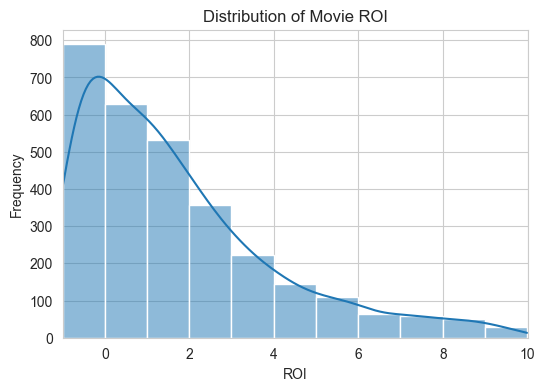

In [13]:
plt.figure(figsize=(6, 4))
sns.histplot(movies['ROI'], bins=11, kde=True)

plt.title("Distribution of Movie ROI")
plt.xlabel("ROI")
plt.ylabel("Frequency")

plt.xlim(-1, 10)
plt.show()

The distribution of ROI is right-skewed with most movies clustered around negative (-1 to 0) or low/moderate (0 to 2) returns, and an increasingly smaller number achieving very high (6-10). profitability. These results indicate that a significant proportion of films fail due to inherent risk in movie production. However, when a movie succeeds, there is an opportunity for returns to be magnitudes higher than the initial budget.

### ROI vs Popularity

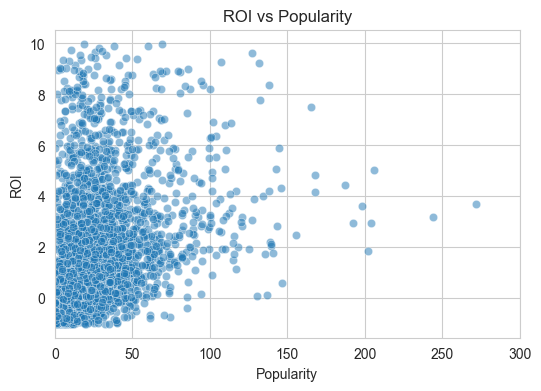

In [14]:
plt.figure(figsize=(6, 4))

sns.scatterplot(x=movies['popularity'], y=movies['ROI'], alpha=0.5)

plt.title("ROI vs Popularity")
plt.xlabel("Popularity")
plt.ylabel("ROI")

plt.xlim(0, 300)
plt.show()

The relationship between popularity and ROI appears to be weakly positive but highly dispersed. While more popular movies tend to achieve higher returns on average, there is significant variability, indicating that popularity alone is not a strong predictor of financial success. This suggests that popularity may contribute useful signal in modeling, but should be combined with other features for better predictive performance.

### Top 10 Genres by Average ROI

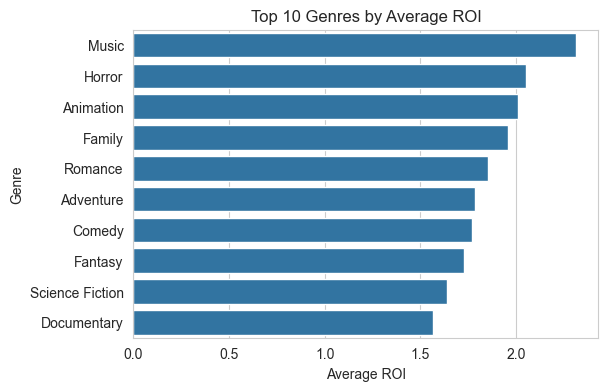

In [15]:
# Gives each genre its own row for movies with multiple genres
genres_exploded = movies.explode('genres')

# Group genre_exploded by ROI and then calculate the mean before sorting them in descending order
genre_roi = (
    genres_exploded.groupby('genres')['ROI']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=genre_roi.head(10).values,
    y=genre_roi.head(10).index
)
plt.title("Top 10 Genres by Average ROI")
plt.xlabel("Average ROI")
plt.ylabel("Genre")

plt.show()

Average ROI varies noticeably across genres. Genres such as Music, Horror, and Animation tend to exhibit higher average returns, while others show more moderate performance. This suggests that genre plays a meaningful role in financial success and may be an important feature in predictive modeling.

### Feature Engineering

To improve model performance and better capture the factors influencing movie success, we construct several new features from the original dataset. These features are designed to incorporate fi

In [16]:
# Number of genres that will help capture how broad the movie is
movies['num_genres'] = movies['genres'].apply(len)

# Number of production companies involved with the movie
movies['num_production_companies'] = movies['production_companies'].apply(len)

# Number of countries involved in the production of the movie
movies['num_countries'] = movies['production_countries'].apply(len)

In [17]:
genres_exploded = movies[['genres']].explode('genres')
genre_dummies = pd.get_dummies(genres_exploded['genres'])

# Aggregate back to movie level
genre_dummies = genre_dummies.groupby(level=0).max()

# Merge back into original dataframe
movies = pd.concat([movies, genre_dummies], axis=1)

Several features were constructed to enhance the predictive power of the models. We created numerical features capturing structural aspects of each film, including the number of genres, production companies, and production countries, which reflect the scope and scale of a movie’s production.

Additionally, since movies can belong to multiple genres, the genres column was transformed by expanding the genre lists and creating binary indicators for each genre, allowing the model to capture genre-specific effects on financial success.

# Modelling

In [18]:
# Remove columns we will not need before beginning the modelling section
movies_model = movies.drop(columns=[
    'genres',
    'budget',
    'revenue',
    'production_companies',
    'production_countries',
    'original_title'
])
movies_model

,popularity,runtime,vote_average,vote_count,ROI,success,num_genres,num_production_companies,num_countries,Action,...,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
1,139.082615,169.0,6.9,4500,2.203333,1,3,3,1,True,...,False,False,False,False,False,False,False,False,False,False
2,107.376788,148.0,6.3,4466,2.594590,1,3,3,2,True,...,False,False,False,False,False,False,False,False,False,False
3,112.312950,165.0,7.6,9106,3.339756,1,4,4,1,True,...,False,False,False,False,False,False,False,True,False,False
4,43.926995,132.0,6.1,2124,0.092843,0,3,1,1,True,...,False,False,False,False,False,False,True,False,False,False
5,115.699814,139.0,5.9,3576,2.452991,1,3,3,1,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4752,2.380332,99.0,5.6,59,5.407662,1,3,1,1,False,...,False,False,False,False,False,True,False,False,False,False
4758,27.662696,95.0,5.8,631,-0.849776,0,2,3,1,False,...,False,False,False,False,False,False,True,True,False,False
4772,1.330379,89.0,6.3,26,-0.679405,0,3,0,1,True,...,False,False,False,False,False,False,False,False,False,False
4792,0.212443,111.0,7.4,63,3.950000,1,4,1,1,False,...,False,False,True,False,True,False,False,True,False,False


In [19]:
# Define X and y variables for classification and regression for our model
X = movies_model.drop(columns=['success', 'ROI'])
y_reg = movies_model['ROI']
y_clf = movies_model['success']

Splitting the data using indices to ensure consistent observations are used across both regression and classification tasks.

In [20]:
# Splitting the data for regression and classification

# Train-test split
train_idx, test_idx = train_test_split(movies_model.index, test_size=0.2, random_state=42)

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

# For regression
y_reg_train = y_reg.loc[train_idx]
y_reg_test = y_reg.loc[test_idx]

# For classification
y_clf_train = y_clf.loc[train_idx]
y_clf_test = y_clf.loc[test_idx]

Before applying regularization methods like Lasso, we scale the features to have mean of 0 and standard deviation of 1. This ensure that the reguralization penalty is applied equally to all coeficients.

In [21]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Feature selection with CV

We use LassoCV on the training data to select the most relevant features for predicting ROI. Cross-validation is used to choose the optimal regularization parameter, and features with non-zero coefficients are kept. These selected features are then used to create the final training and test datasets for the next modeling steps.

Feature selection is performed using Lasso regression on ROI, as it provides a continuous measure of financial performance and helps identify features with strong predictive signal.

In [25]:
lasso_cv = LassoCV(cv=5, random_state=42, alphas=np.linspace(0.001,1, 100), max_iter=10000)
lasso_cv.fit(X_train_scaled, y_reg_train)

# Feature selection
selected = lasso_cv.coef_ != 0
selected_features = X.columns[selected]

# Rebuild the train and test using only selelcted features
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

# Scale again using only selected features
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

print(f"features selected: {np.sum(selected)}")
print(f"best alpha: {lasso_cv.alpha_:.4f}")
print(f"features selected: {selected_features.to_list()}")

features selected: 23
best alpha: 0.0111
features selected: ['popularity', 'runtime', 'vote_average', 'vote_count', 'num_genres', 'num_production_companies', 'num_countries', 'Action', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'Western']


The lasso model selected 23 features with small alpha, meaning most variables are still useful for predicting ROI. The model reduces some features and keeps most of the important ones. The selected features are used as inputs for the regression and classification models in the next section.

In [26]:
pd.Series(lasso_cv.coef_, index=X.columns).sort_values()

runtime                    -0.201077
Drama                      -0.178537
Science Fiction            -0.146871
num_countries              -0.110695
Animation                  -0.108977
Action                     -0.086160
num_genres                 -0.076693
Fantasy                    -0.073541
Foreign                    -0.070434
Crime                      -0.068721
Western                    -0.047672
num_production_companies   -0.044541
Documentary                -0.027307
Mystery                    -0.026643
Thriller                   -0.000831
Adventure                   0.000000
War                         0.000000
History                     0.000000
Family                      0.065538
Comedy                      0.070034
Romance                     0.103503
Music                       0.132817
Horror                      0.175242
popularity                  0.261862
vote_count                  0.516344
vote_average                0.537058
dtype: float64

Multiple machine learning models were developed to analyze movie performance and profitability using historical financial and rating data. Regression models were implemented to predict continuous Return on Investment (ROI) values, while classification models were used to determine whether a movie is profitable. Five-fold cross-validation was applied to evaluate model stability and reduce the risk of overfitting, ensuring reliable and generalizable performance. Both linear models (such as Linear Regression and Logistic Regression) and ensemble methods (such as Random Forest) were implemented to compare different modeling approaches and identify the most effective models for prediction. This modeling strategy allows for a comprehensive evaluation of model performance and supports data-driven decision-making.

### Regression Model with Cross-Validation

#### Linear Regression

A Linear Regression model was used as a baseline to predict Return on Investment (ROI). Five-fold cross-validation was applied to evaluate model stability.

In [27]:
linear_reg = LinearRegression()

cv_scores = cross_val_score(
    linear_reg,
    X_train_final_scaled,
    y_reg_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

rmse_linear = np.sqrt(-cv_scores)

print("Linear Regression CV RMSE:", rmse_linear.mean())

Linear Regression CV RMSE: 2.0637024992946964


In [28]:
linear_reg.fit(X_train_final_scaled, y_reg_train)
y_pred_reg = linear_reg.predict(X_test_final_scaled)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
mae = mean_absolute_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test RMSE: 2.187696275213873
Test MAE: 1.610518014317888
Test R2: 0.1758348214387424


The model achieved a cross-validation RMSE of approximately 2.06, and a test RMSE of 2.19, indicating consistent performance between training and testing data. The R² value of 0.18 suggests that the model explains a modest portion of the variance in ROI. This model provides a simple and interpretable benchmark for comparison with more complex models.

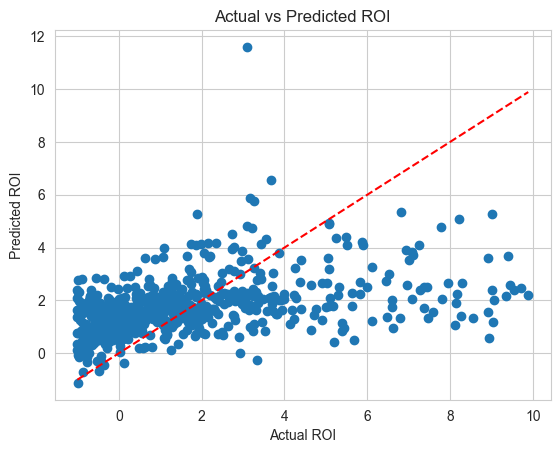

In [45]:
plt.scatter(y_reg_test, y_pred_reg)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], color='red', linestyle='--')
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")

plt.title("Actual vs Predicted ROI")

plt.show()

The scatter plot compares actual ROI values with predicted ROI values from the Linear Regression model. Points closer to the diagonal line would indicate more accurate predictions. The spread of points shows that predictions vary across the dataset, suggesting that ROI is influenced by factors not fully captured by the model. However, the model still provides reasonable predictions for many observations.

#### Ridge Regression

Ridge Regression was implemented to address potential multicollinearity and reduce overfitting through regularization.

In [ ]:
ridge = RidgeCV(
    alphas=[0.01, 0.1, 1, 10],
    cv=5
)

ridge.fit(X_train_final_scaled, y_reg_train)
y_pred_ridge = ridge.predict(X_test_final_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge))

ridge_mae = mean_absolute_error(
    y_reg_test,
    y_pred_ridge
)

ridge_r2 = r2_score(
    y_reg_test,
    y_pred_ridge
)

print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge R2:", ridge_r2)

Ridge RMSE: 2.187809714341154
Ridge MAE: 1.610606119962991
Ridge R2: 0.17574934796274233


In [35]:
cv_scores_ridge = cross_val_score(
    ridge,
    X_train_final_scaled,
    y_reg_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

cv_rmse_ridge = np.sqrt(-cv_scores_ridge)

print("Ridge CV RMSE:", cv_rmse_ridge.mean())

Ridge CV RMSE: 2.063234708996318


The Ridge model produced an RMSE very similar to Linear Regression, indicating that regularization did not significantly improve predictive performance. This suggests that the selected features are relatively stable and not heavily affected by multicollinearity.

#### Random Forest Regressor

A Random Forest Regressor was implemented to capture potential nonlinear relationships between movie features and ROI.

In [31]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

cv_scores_rf = cross_val_score(
    rf_reg,
    X_train_final,
    y_reg_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

cv_rmse_rf = np.sqrt(-cv_scores_rf)

print("Random Forest CV RMSE:", cv_rmse_rf.mean())

Random Forest CV RMSE: 2.0069587970650664


In [33]:
rf_reg.fit(X_train_final, y_reg_train)

y_pred_rf = rf_reg.predict(X_test_final)

rf_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf))
rf_r2 = r2_score(y_reg_test, y_pred_rf)
rf_mae = mean_absolute_error(
    y_reg_test,
    y_pred_rf
)

print("Random Forest Test RMSE:", rf_rmse)
print("Random Forest Test R2:", rf_r2)
print("Random Forest Test MAE:", rf_mae)

Random Forest Test RMSE: 2.168515518990433
Random Forest Test R2: 0.1902233014863185
Random Forest Test MAE: 1.5702842224342632


The model achieved the lowest RMSE among the regression models, indicating slightly improved predictive accuracy. Although the improvement over linear models was modest, the Random Forest model demonstrates the benefit of using more flexible machine learning methods for complex data patterns.

#### Comparison for Regression Model

In [34]:
print("Linear Regression RMSE:", rmse)
print("Ridge Regression RMSE:", ridge_rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 2.187696275213873
Ridge Regression RMSE: 2.187809714341154
Random Forest RMSE: 2.168515518990433


Three regression models were evaluated to predict ROI: Linear Regression, Ridge Regression, and Random Forest Regression. All models produced similar performance, with the Random Forest model achieving the lowest RMSE. This indicates that the relationship between the selected features and ROI is relatively stable and not highly nonlinear. Based on RMSE performance, the Random Forest model was selected as the best-performing regression model.

### Classification Model with Cross-Validation

#### Logistic Regression

Logistic Regression was used to classify whether a movie is profitable. Five-fold cross-validation was applied to evaluate model stability.

In [36]:
logistic_reg = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(
    logistic_reg,
    X_train_final_scaled,
    y_clf_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy:", cv_scores.mean())

Logistic Regression CV Accuracy: 0.7060077366385096


In [37]:
logistic_reg.fit(X_train_final_scaled, y_clf_train)
y_pred_clf = logistic_reg.predict(X_test_final_scaled)

logistic_clf_acc = accuracy_score(y_clf_test, y_pred_clf)
logistic_clf_prec = precision_score(y_clf_test, y_pred_clf)
logistic_clf_rec = recall_score(y_clf_test, y_pred_clf)
logistic_clf_f1 = f1_score(y_clf_test, y_pred_clf)

print("Accuracy:", logistic_clf_acc)
print("Precision:", logistic_clf_prec)
print("Recall:", logistic_clf_rec)
print("F1:", logistic_clf_f1)

Accuracy: 0.7157190635451505
Precision: 0.711340206185567
Recall: 0.5476190476190477
F1: 0.6188340807174888


The model achieved an accuracy of approximately 0.72, indicating that it correctly classified profitability for most observations. Precision and recall values suggest a reasonable balance between correctly identifying profitable movies and avoiding false predictions. Logistic Regression provides a simple and interpretable classification baseline.

#### ROC Curve for Logistic Regression

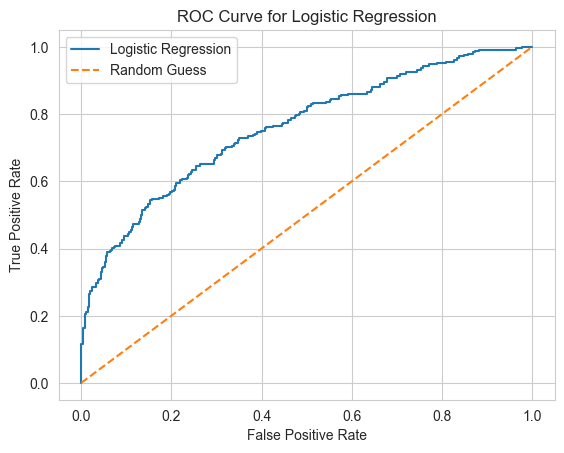

AUC: 0.759289843104872


In [38]:
y_prob = logistic_reg.predict_proba(X_test_final_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")

plt.legend()
plt.show()

print("AUC:", roc_auc)

The ROC curve evaluates the Logistic Regression model’s ability to distinguish between profitable and non-profitable movies across different classification thresholds. The Area Under the Curve (AUC) value of 0.76 indicates that the model has good discriminative ability and performs significantly better than random guessing. This result confirms that the selected features provide meaningful information for predicting movie profitability.

#### Confusion matrix for Logistic Regression

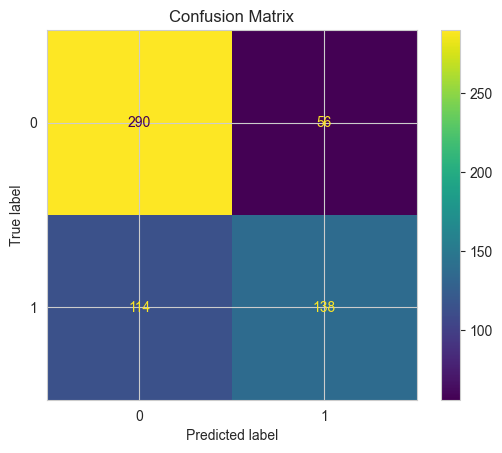

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_clf_test,
    y_pred_clf
)

plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows the number of correct and incorrect predictions made by the Logistic Regression model. The model correctly identified a large number of non-profitable and profitable movies, but some misclassifications remain. This visualization helps evaluate model performance beyond accuracy by showing how predictions are distributed across classes.

#### Random Forest Classification

A Random Forest Classifier was implemented to capture nonlinear relationships in the classification task.

In [40]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

cv_scores_rf_clf = cross_val_score(
    rf_clf,
    X_train_final,
    y_clf_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest Classification CV Accuracy:", cv_scores_rf_clf.mean())

Random Forest Classification CV Accuracy: 0.7143926037034113


In [41]:
rf_clf.fit(X_train_final, y_clf_train)
y_pred_rf_clf = rf_clf.predict(X_test_final)

rf_clf_acc = accuracy_score(y_clf_test, y_pred_rf_clf)
rf_clf_prec = precision_score(y_clf_test, y_pred_rf_clf)
rf_clf_rec = recall_score(y_clf_test, y_pred_rf_clf)
rf_clf_f1 = f1_score(y_clf_test, y_pred_rf_clf)
y_prob_rf_clf = rf_clf.predict_proba(X_test_final)[:,1]

rf_clf_auc = roc_auc_score(
    y_clf_test,
    y_prob_rf_clf
)

print("Random Forest Classification Test Accuracy:", rf_clf_acc)
print("Random Forest Classification Test Precision:", rf_clf_prec)
print("Random Forest Classification Test Recall:", rf_clf_rec)
print("Random Forest Classification Test F1:", rf_clf_f1)
print("Random Forest Classification AUC:", rf_clf_auc)

Random Forest Classification Test Accuracy: 0.7207357859531772
Random Forest Classification Test Precision: 0.6995305164319249
Random Forest Classification Test Recall: 0.5912698412698413
Random Forest Classification Test F1: 0.6408602150537634
Random Forest Classification AUC: 0.7817116249197174


The model achieved slightly higher accuracy than Logistic Regression, indicating improved classification performance. The Random Forest model demonstrates the advantage of ensemble methods in handling complex feature interactions and improving prediction reliability.

#### Comparison for Classification Model

In [42]:
print("Logistic Regression Accuracy:", accuracy_score(y_clf_test, y_pred_clf))
print("Random Forest Classification Accuracy:", rf_clf_acc)

Logistic Regression Accuracy: 0.7157190635451505
Random Forest Classification Accuracy: 0.7207357859531772


Two classification models were evaluated to predict movie profitability: Logistic Regression and Random Forest Classification. Both models produced similar performance, with the Random Forest model achieving slightly higher accuracy. This suggests that ensemble methods may better capture complex relationships in the data. Based on overall accuracy and F1 score, the Random Forest classifier was selected as the best-performing classification model.

In [46]:
feature_importance = pd.Series(rf_reg.feature_importances_, index=selected_features).sort_values(ascending=False)
print(feature_importance.head(10))

vote_count                  0.360617
vote_average                0.127818
popularity                  0.126761
runtime                     0.118627
num_production_companies    0.057845
num_genres                  0.036505
Action                      0.022121
Romance                     0.019087
num_countries               0.018937
Comedy                      0.015061
dtype: float64


The Random Forest model identifies vote_count as the most influential predictor of financial success, suggesting that audience engagement is a strong indicator of ROI. Other key features include vote_average, popularity, and runtime, which also contribute meaningfully to predicting ROI.

### Advanced Modelling

To extend the baseline and regularized regression models, we implemented an additional advanced model based on spline transformations. Unlike standard linear regression, spline-based models can capture nonlinear relationships between predictors and ROI

In [38]:
spline_reg = make_pipeline(
    SplineTransformer(n_knots=5, degree=3, include_bias=False),
    Ridge(alpha=1.0)
)

cv_scores_spline = cross_val_score(
    spline_reg,
    X_train_final_scaled,
    y_reg_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

cv_rmse_spline = np.sqrt(-cv_scores_spline)

print("Spline Regression CV RMSE:", cv_rmse_spline.mean())

Spline Regression CV RMSE: 2.0151408022243182


In [39]:
spline_reg.fit(X_train_final_scaled, y_reg_train)

y_pred_spline = spline_reg.predict(X_test_final_scaled)

spline_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_spline))
spline_mae = mean_absolute_error(y_reg_test, y_pred_spline)
spline_r2 = r2_score(y_reg_test, y_pred_spline)

print("Spline Regression Test RMSE:", spline_rmse)
print("Spline Regression Test MAE:", spline_mae)
print("Spline Regression Test R2:", spline_r2)

Spline Regression Test RMSE: 2.1474850341439033
Spline Regression Test MAE: 1.564307028813615
Spline Regression Test R2: 0.2058537335640801


The spline regression model was introduced to capture smoother nonlinear relationships between movie features and ROI. This makes it a useful complement to both Linear/Ridge Regression and Random Forest.

Spline regression was implemented using a SplineTransformer combined with Ridge regression. The spline transformation creates multiple smooth basis functions, allowing the model to capture curved patterns while the Ridge component helps control model complexity and prevent overfitting.

The spline regression achieved a cross-validation RMSE of approximately **2.015**, indicating competitive performance compared to earlier models. When evaluated on the test set, the spline regression model achieved a Test RMSE of **2.147**, Test MAE of **1.564**, and Test R² of **0.206**. This represents an improvement over the Linear, Ridge, and Random Forest models, suggesting that nonlinear relationships play an important role in predicting movie ROI.


### Test Set Evaluation

All models are trained using the training set and optimized using cross-validation. The test set is reserved exclusively for final evaluation and is not used during model training or parameter tuning.

Regression models are evaluated using RMSE, MAE, and R² to assess prediction error and explanatory power. Classification models are evaluated using Accuracy, Precision, Recall, and F1-score to measure classification performance.

This evaluation strategy ensures that the reported performance reflects the true generalization ability of each model.

#### Regression Test Set Evaluation

In [44]:
results_regression = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Spline Regression"
    ],
    "Test RMSE": [
        rmse,
        ridge_rmse,
        rf_rmse,
        spline_rmse
    ],
    "Test MAE": [
        mae,
        ridge_mae,
        rf_mae,
        spline_mae
    ],
    "Test R2": [
        r2,
        ridge_r2,
        rf_r2,
        spline_r2
    ]
})

results_regression = results_regression.sort_values("Test RMSE")
results_regression

,Model,Test RMSE,Test MAE,Test R2
3,Spline Regression,2.147485,1.564307,0.205854
2,Random Forest,2.168516,1.570284,0.190223
0,Linear Regression,2.187696,1.610518,0.175835
1,Ridge Regression,2.187810,1.610606,0.175749


Among the regression models, the Spline Regression model achieved the lowest Test RMSE (**2.147**) and the highest R² (**0.206**), indicating the best predictive performance among all models. 

Compared to Linear and Ridge Regression, the improvement suggests that nonlinear relationships exist between movie features and ROI. While the Random Forest model also improved performance relative to linear models, the spline approach provided the most consistent reduction in prediction error.

#### Classification Test Set Evaluation

In [43]:
results_classification = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest Classifier"
    ],
    "Accuracy": [
        logistic_clf_acc,
        rf_clf_acc
    ],
    "Precision": [
        logistic_clf_prec,
        rf_clf_prec
    ],
    "Recall": [
        logistic_clf_rec,
        rf_clf_rec
    ],
    "F1 Score": [
        logistic_clf_f1,
        rf_clf_f1
    ],
    "ROC AUC": [
        roc_auc,
        rf_clf_auc
    ]
})

results_classification.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest Classifier,0.720736,0.699531,0.591270,0.640860,0.781712
0,Logistic Regression,0.715719,0.711340,0.547619,0.618834,0.759290


The Random Forest Classifier achieved the best classification performance among the evaluated models. It achieved an Accuracy of **0.721**, slightly higher than Logistic Regression (**0.716**). 

More importantly, the Random Forest model demonstrated improved Recall (**0.591**) and F1-score (**0.641**), indicating a stronger ability to correctly identify positive cases. This improvement is also reflected in the ROC AUC score, where Random Forest achieved **0.782**, outperforming Logistic Regression (**0.759**).

#### Overall Model Comparison

Across the regression models, the **Spline Regression model** achieved the best predictive performance, with the lowest RMSE (**2.147**) and highest R² (**0.206**). This indicates that modelling nonlinear relationships significantly improves prediction accuracy for movie ROI.

For classification tasks, the **Random Forest Classifier** demonstrated the strongest performance, achieving the highest Accuracy (**0.721**) and ROC AUC (**0.782**). This suggests that ensemble methods are particularly effective in distinguishing between successful and unsuccessful movie outcomes.

Overall, the results indicate that more flexible modelling approaches, such as spline regression and ensemble-based classifiers, provide measurable improvements over traditional linear models.

# Conclusion